In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os

In [2]:
# Load Data hasil filter Orang 2 (Otomatis berisi 6 Genre)
df = pd.read_csv("../Data/features/combined_features.csv")
X = df.drop(columns=['nama_file', 'label_genre'])
y = df['label_genre']

In [3]:
# Preprocessing Data Tabular
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

os.makedirs("../models", exist_ok=True)

PROSES MODEL MACHINE LEARNING: SVM
              precision    recall  f1-score   support

       blues       0.90      0.93      0.91       200
   classical       0.91      0.97      0.94       200
     country       0.82      0.81      0.81       199
        jazz       0.89      0.86      0.88       198
         pop       0.96      0.88      0.91       200
        rock       0.80      0.82      0.81       200

    accuracy                           0.88      1197
   macro avg       0.88      0.88      0.88      1197
weighted avg       0.88      0.88      0.88      1197



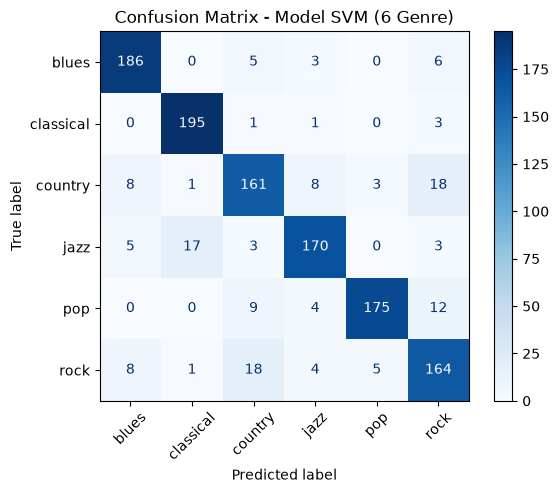

In [4]:
# --- 1. MODEL SVM ---
print("="*60, "\nPROSES MODEL MACHINE LEARNING: SVM\n", "="*60)
model_svm = SVC(kernel='rbf', C=1.0, random_state=42)
model_svm.fit(X_train_scaled, y_train)
pred_svm = model_svm.predict(X_test_scaled)

# Evaluasi Lengkap SVM (Tahap 8)
print(classification_report(y_test, pred_svm, target_names=le.classes_))
cm_svm = confusion_matrix(y_test, pred_svm)
ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_).plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Model SVM (6 Genre)")
plt.xticks(rotation=45)
plt.show()

PROSES MODEL MACHINE LEARNING: RANDOM FOREST
              precision    recall  f1-score   support

       blues       0.91      0.92      0.91       200
   classical       0.92      0.97      0.95       200
     country       0.83      0.80      0.82       199
        jazz       0.78      0.86      0.82       198
         pop       0.94      0.89      0.91       200
        rock       0.82      0.76      0.79       200

    accuracy                           0.87      1197
   macro avg       0.87      0.87      0.87      1197
weighted avg       0.87      0.87      0.87      1197



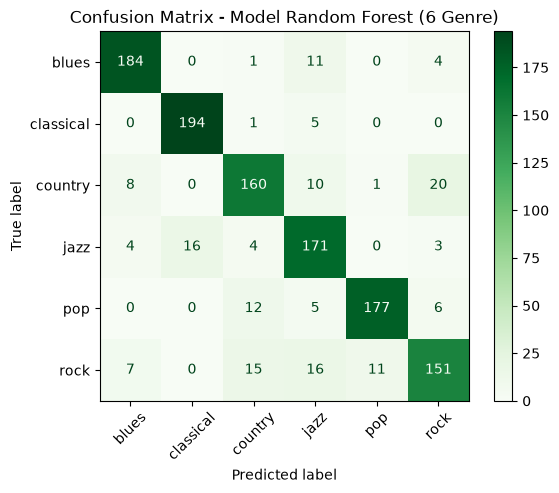

In [5]:
# --- 2. MODEL RANDOM FOREST ---
print("="*60, "\nPROSES MODEL MACHINE LEARNING: RANDOM FOREST\n", "="*60)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)
pred_rf = model_rf.predict(X_test_scaled)

# Evaluasi Lengkap RF (Tahap 8)
print(classification_report(y_test, pred_rf, target_names=le.classes_))
cm_rf = confusion_matrix(y_test, pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=le.classes_).plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Model Random Forest (6 Genre)")
plt.xticks(rotation=45)
plt.show()

In [6]:
# Save hasil latihan
joblib.dump(model_svm, "../models/svm_genre_model.pkl")
joblib.dump(model_rf, "../models/rf_genre_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(le, "../models/label_encoder.pkl")
print("\n[SUKSES]")


[SUKSES]
